# Previsão de Churn em Telecom

### Um projeto de Machine Learning aplicado à retenção de clientes

Este projeto tem como objetivo analisar o comportamento de clientes de uma empresa de telecomunicações e desenvolver um modelo capaz de identificar clientes com maior probabilidade de cancelamento.

A ideia é ir além da previsão: entender quais características estão mais relacionadas ao churn e transformar essas informações em apoio para estratégias de retenção.

## 1. Contexto do problema

A perda de clientes, conhecida como **churn**, é um dos principais desafios para empresas de serviços recorrentes, como as operadoras de telecomunicações.

Conquistar um novo cliente normalmente exige investimento em aquisição, enquanto a retenção de um cliente existente pode representar uma oportunidade de preservar receita e relacionamento.

Neste projeto, o problema pode ser resumido em uma pergunta:

**Quais clientes apresentam maior probabilidade de cancelar o serviço?**

Para responder a essa pergunta, serão analisados dados sobre perfil, serviços contratados, tipo de contrato, tempo de permanência e informações de cobrança.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

## 2. Carregando os dados

O conjunto de dados utilizado reúne informações de clientes de uma empresa de telecomunicações.

Entre as informações disponíveis estão características do cliente, serviços contratados, tipo de contrato, tempo de permanência e valores de cobrança.

A variável **Churn** será utilizada como variável-alvo do modelo, indicando se o cliente permaneceu ou cancelou o serviço.

In [5]:
df = pd.read_csv(
    'WA_Fn-UseC_-Telco-Customer-Churn.csv'
)

print('Quantidade de linhas:', df.shape[0])
print('Quantidade de colunas:', df.shape[1])

df.head()

Quantidade de linhas: 7043
Quantidade de colunas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Conhecendo as variáveis

Antes de construir o modelo, é importante entender o que cada informação representa e por que ela pode ser relevante para a análise.

Algumas das principais variáveis são:

**tenure** — representa há quantos meses o cliente está na empresa. Essa informação permite observar se o tempo de relacionamento está associado ao cancelamento.

**Contract** — indica o tipo de contrato do cliente. Contratos com diferentes níveis de compromisso podem apresentar comportamentos distintos em relação ao churn.

**MonthlyCharges** — representa o valor cobrado mensalmente. Essa variável ajuda a analisar a relação entre o custo recorrente e o cancelamento.

**TotalCharges** — representa o total acumulado de cobranças do cliente durante o período analisado.

**PaymentMethod** — indica a forma utilizada pelo cliente para realizar os pagamentos.

**InternetService** — identifica o tipo de serviço de internet contratado.

**Churn** — indica se o cliente cancelou o serviço. Essa será a variável que o modelo tentará prever.

In [7]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


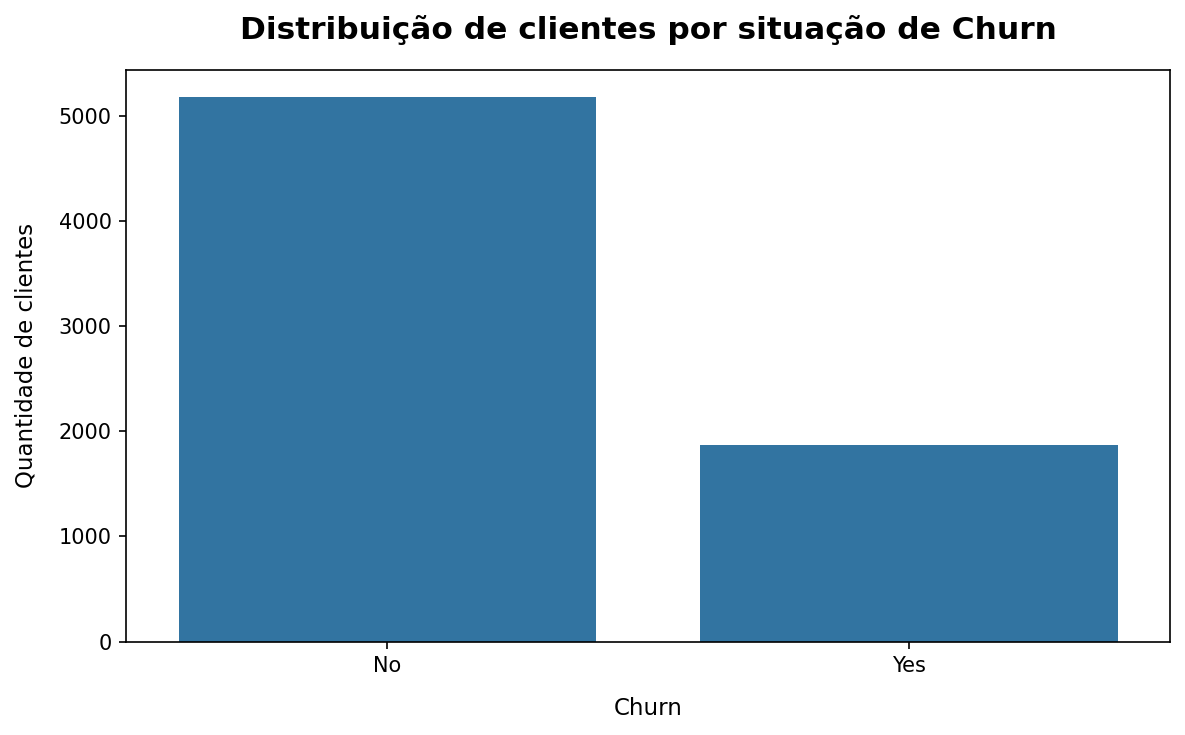

In [8]:
fig, ax = plt.subplots(
    figsize=(8, 5),
    dpi=150
)

sns.countplot(
    data=df,
    x='Churn',
    ax=ax
)

ax.set_title(
    'Distribuição de clientes por situação de Churn',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Churn',
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    'Quantidade de clientes',
    fontsize=11,
    labelpad=10
)

ax.tick_params(
    axis='both',
    labelsize=10
)

plt.tight_layout()

plt.savefig(
    'distribuicao-churn.png',
    dpi=150,
    bbox_inches='tight'
)

### Primeira observação

A distribuição mostra que a quantidade de clientes que permaneceu na empresa é maior do que a quantidade de clientes que cancelou.

Isso significa que as classes não estão perfeitamente equilibradas.

Por esse motivo, a **acurácia não deve ser analisada sozinha**. Em um problema de churn, também é importante observar métricas como **recall, precisão, F1-score e ROC-AUC**.

O recall merece atenção especial porque representa a capacidade do modelo de identificar os clientes que realmente cancelaram.

## 4. Tratamento inicial dos dados

Antes da modelagem, algumas informações precisam ser preparadas.

A coluna `customerID` será removida porque funciona apenas como identificador do cliente e não possui utilidade direta para a previsão.

A coluna `TotalCharges` será convertida para formato numérico. Alguns registros podem apresentar valores ausentes após essa conversão.

O preenchimento desses valores será realizado posteriormente dentro do pipeline de pré-processamento. Dessa forma, as informações utilizadas para preencher os dados do conjunto de teste não influenciam o treinamento do modelo.

In [9]:
df = df.drop(
    columns=['customerID'],
    errors='ignore'
)

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

df.isna().sum().sort_values(
    ascending=False
).head(10)

,0
TotalCharges,11
gender,0
Partner,0
SeniorCitizen,0
Dependents,0
tenure,0
MultipleLines,0
PhoneService,0
OnlineSecurity,0
OnlineBackup,0


## 5. Análise exploratória

Antes de treinar o modelo, algumas relações entre as variáveis e o churn serão analisadas.

O objetivo desta etapa é identificar padrões que possam ajudar a interpretar o comportamento dos clientes.

Essas análises mostram **associações observadas nos dados**. Elas não significam, por si só, que uma variável seja a causa do cancelamento.

### Churn por tipo de contrato

O tipo de contrato pode estar relacionado ao nível de compromisso do cliente com a empresa.

A seguir, será calculada a taxa de churn para cada tipo de contrato, permitindo comparar quais grupos apresentam maior proporção de cancelamentos.

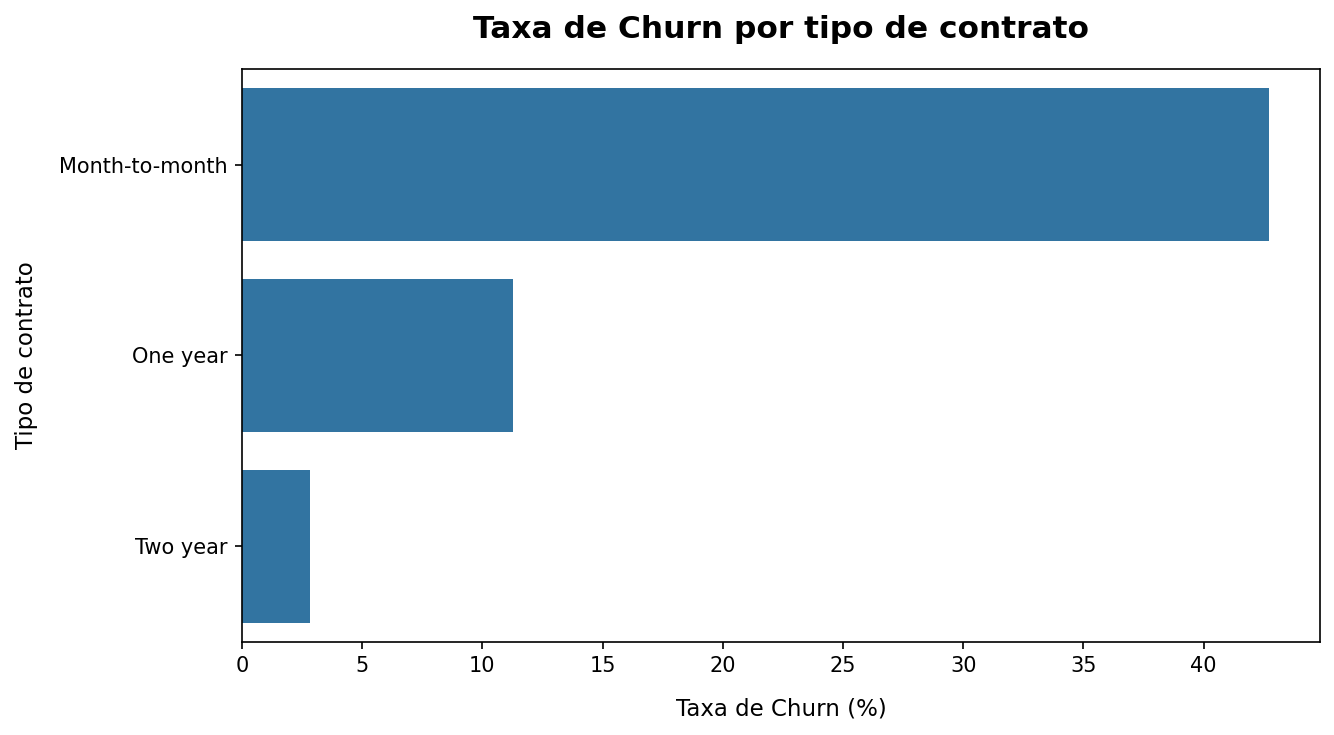

In [10]:
taxa_contrato = (
    df.groupby('Contract')['Churn']
    .mean()
    .sort_values(ascending=False)
    .mul(100)
)

fig, ax = plt.subplots(
    figsize=(9, 5),
    dpi=150
)

sns.barplot(
    x=taxa_contrato.values,
    y=taxa_contrato.index,
    ax=ax
)

ax.set_title(
    'Taxa de Churn por tipo de contrato',
    fontsize=15,
    fontweight='bold',
    pad=15
)

ax.set_xlabel(
    'Taxa de Churn (%)',
    fontsize=11,
    labelpad=10
)

ax.set_ylabel(
    'Tipo de contrato',
    fontsize=11,
    labelpad=10
)

ax.tick_params(
    axis='both',
    labelsize=10
)

plt.tight_layout()

plt.savefig(
    'churn-por-contrato.png',
    dpi=150,
    bbox_inches='tight'
)